# Master's Thesis Notebook

This notebook is part of the **Master's Thesis (MSc Dissertation)**: **Fast Simulation of Neutrino Oscillations in Matter**.

**Author**  
Juan Ramon Diaz Santos <diazjuan@alumni.uv.es>

**Supervisors**  
Roberto Ruiz de Austri Bazan <rruiz@ific.uv.es>  
Michele Lucente <michele.lucente@unibo.it>

**Date**  
June 2026


# test6 flux

Notebook equivalent of `tests/7_atmosphere/test6_flux.py`. The original Python test module remains the source of truth; this notebook imports it and runs each numerical test and diagnostic plot in its own cell for interactive inspection.

The notebook uses the shared TPeanuts output-root convention defined in section `2. Paths`. Generated `atmosphere` test artifacts and figures are redirected to the notebook-specific `OUTPUT_DIR` under `OUTPUT_TEST_ROOT / "atmosphere" / NOTEBOOK_STEM`.


## 1. Libraries and test module

This section locates the repository, imports the original `atmosphere` test module, and reloads it so source changes are reflected when the notebook is rerun. The expected result is that the module imports without errors. Possible problems include running the notebook from outside the repository tree, missing optional dependencies, or unavailable external model data.


In [1]:
from __future__ import annotations

import importlib
import importlib.util
import os
import sys
import traceback
from pathlib import Path

import matplotlib.pyplot as plt


from tpeanuts.util.notebooks import find_repo_root
HERE = Path.cwd().resolve()
PACKAGE_DIR = find_repo_root(HERE, folder="analysis")
print(f"PACKAGE_DIR = {PACKAGE_DIR}")

NOTEBOOK_STEM = "test6_fluxt"
TEST_MODULE_PATH = PACKAGE_DIR / "notebooks" / "tests" / "7_atmosphere" / f"{NOTEBOOK_STEM}.py"
TEST_MODULE_NAME = f"notebook_tests_{TEST_MODULE_PATH.parent.name.replace('.', '_')}_{NOTEBOOK_STEM}"
if not TEST_MODULE_PATH.exists():
    raise FileNotFoundError(f"Could not find local test module: {TEST_MODULE_PATH}")
spec = importlib.util.spec_from_file_location(TEST_MODULE_NAME, TEST_MODULE_PATH)
if spec is None or spec.loader is None:
    raise ImportError(f"Could not load test module spec from {TEST_MODULE_PATH}")
TEST_MODULE = importlib.util.module_from_spec(spec)
sys.modules[TEST_MODULE_NAME] = TEST_MODULE
spec.loader.exec_module(TEST_MODULE)
print("Loaded local test module:", TEST_MODULE_PATH)

from tpeanuts.util.notebooks import build_notebook_test_runner


PACKAGE_DIR = G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts
Loaded local test module: G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\notebooks\tests\7_atmosphere\test6_fluxt.py


## 2. Paths

All outputs are rooted at `DEFAULT_OUTPUT_ROOT` unless `TPEANUTS_OUTPUT_ROOT` is defined in the environment. This notebook writes `atmosphere` test figures and generated artifacts under `OUTPUT_TEST_ROOT / "atmosphere" / NOTEBOOK_STEM`, while data, analysis, benchmark, and external roots follow the same shared structure used by the analysis notebooks.


In [2]:
DEFAULT_OUTPUT_ROOT = Path(r"V:\output")
OUTPUT_ROOT = Path(os.environ.get("TPEANUTS_OUTPUT_ROOT", DEFAULT_OUTPUT_ROOT))

OUTPUT_DATA_ROOT = Path(OUTPUT_ROOT / "data")
OUTPUT_ANALYSIS_ROOT = Path(OUTPUT_ROOT / "analysis")
OUTPUT_BENCHMARK_ROOT = Path(OUTPUT_ROOT / "benchmark")
OUTPUT_TEST_ROOT = Path(OUTPUT_ROOT / "test")

OUTPUT_DATA_ATMOSPHERE = Path(OUTPUT_DATA_ROOT / "atmosphere")
OUTPUT_DATA_SOLAR = Path(OUTPUT_DATA_ROOT / "solar")
OUTPUT_DATA_EXTERNAL = Path(OUTPUT_DATA_ROOT / "external")

OUTPUT_ANALYSIS_ATMOSPHERE = Path(OUTPUT_ANALYSIS_ROOT / "atmosphere")
OUTPUT_ANALYSIS_SOLAR = Path(OUTPUT_ANALYSIS_ROOT / "solar")
OUTPUT_ANALYSIS_EXTERNAL = Path(OUTPUT_ANALYSIS_ROOT / "external")

OUTPUT_DATA_MCEQ = Path(OUTPUT_DATA_EXTERNAL / "mceq")
OUTPUT_DATA_HONDA = Path(OUTPUT_DATA_EXTERNAL / "honda")

OUTPUT_DIR = OUTPUT_TEST_ROOT / "atmosphere" / NOTEBOOK_STEM
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SHOW_PLOTS = True
print("Output root     :", OUTPUT_ROOT)
print("Output directory:", OUTPUT_DIR)


Output root     : V:\output
Output directory: V:\output\test\atmosphere\test6_fluxt


In [3]:
NOTEBOOK_RUNNER_ATTRS = {}
if "RUN_REAL_DATA_ANALYSIS" in globals():
    NOTEBOOK_RUNNER_ATTRS["RUN_REAL_mceq_run1_analysis"] = RUN_REAL_DATA_ANALYSIS

runner = build_notebook_test_runner(
    TEST_MODULE,
    OUTPUT_DIR,
    show_plots=SHOW_PLOTS,
    auto_save_figures=True,
    extra_module_attrs=NOTEBOOK_RUNNER_ATTRS,
)
run_notebook_test = runner.run_test
run_notebook_call = runner.run_call


## Test: `test_atmosphere_flux_diagnostics`

**What is checked:** Atmosphere flux diagnostics behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: assert_true; Python assert expression.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; density backend availability, geometry conventions, or propagation-step settings can affect this check; missing or blank plots may indicate a path, backend, or non-finite numerical-data problem.


### Output files for `test_atmosphere_flux_diagnostics`

This block generates or validates files in `OUTPUT_DIR`:

- `earth_density.csv`
- `test_atmosphere_flux_diagnostics_figure_001.png`
- `test_atmosphere_flux_diagnostics_figure_002.png`
- `test_atmosphere_flux_diagnostics_figure_003.png`
- `test_atmosphere_flux_diagnostics_figure_004.png`

The expected result is that each relevant image or data artifact is written to disk and, for figures, also displayed inline when `SHOW_PLOTS = True`. Possible problems include a non-writable output directory, an inactive Matplotlib backend, missing optional external data, or upstream numerical values that make the plotted curves empty or non-finite.


Running test_atmosphere_flux_diagnostics ...
Using device: cuda
Using device: cuda
earth density loaded.
rj shape: torch.Size([5])

[1] Probability matrix
P.shape       = torch.Size([3, 3])
S_total.shape = torch.Size([3, 3])
Column sums: tensor([1.0000, 1.0000, 1.0000], dtype=torch.float64)
Probability column error = 3.553e-14

[2] flux vector propagation
flux_in     = tensor([1., 2., 0.], dtype=torch.float64)
flux_out    = tensor([1.0000, 1.9830, 0.0170], dtype=torch.float64)
flux_direct = tensor([1.0000, 1.9830, 0.0170], dtype=torch.float64)
flux consistency error = 1.981e-13

[3] Grid flux propagation
nue torch.Size([4, 5])
numu torch.Size([4, 5])
nutau torch.Size([4, 5])

[4] Height integration
nue integrated shape: torch.Size([4])
numu integrated shape: torch.Size([4])
nutau integrated shape: torch.Size([4])

[5] Total flux conservation check
Max relative total-flux error = 1.960e-15

[6] Plot integrated fluxes
Saved plot: V:\output\test\atmosphere\test6_fluxt\test_atmosphere_flux

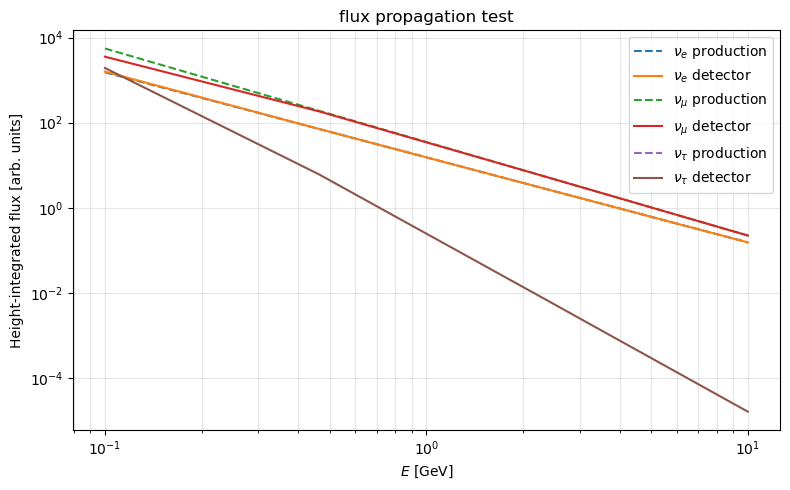


All flux propagation tests passed successfully.

Loaded flux grids:
E_grid shape    = torch.Size([4])
h_grid_km shape = torch.Size([5])
nue torch.Size([4, 5]) cuda:0
numu torch.Size([4, 5]) cuda:0
nutau torch.Size([4, 5]) cuda:0

Integrated flux diagnostics:
nue   | init integral = 8.651825e-05 | det integral = 8.651096e-05
numu  | init integral = 9.590330e-05 | det integral = 9.570251e-05
nutau | init integral = 0.000000e+00 | det integral = 2.080831e-07

Max relative total-flux difference detector vs initial = 6.244e-15
Saved plot: V:\output\test\atmosphere\test6_fluxt\test_atmosphere_flux_diagnostics_figure_002.png


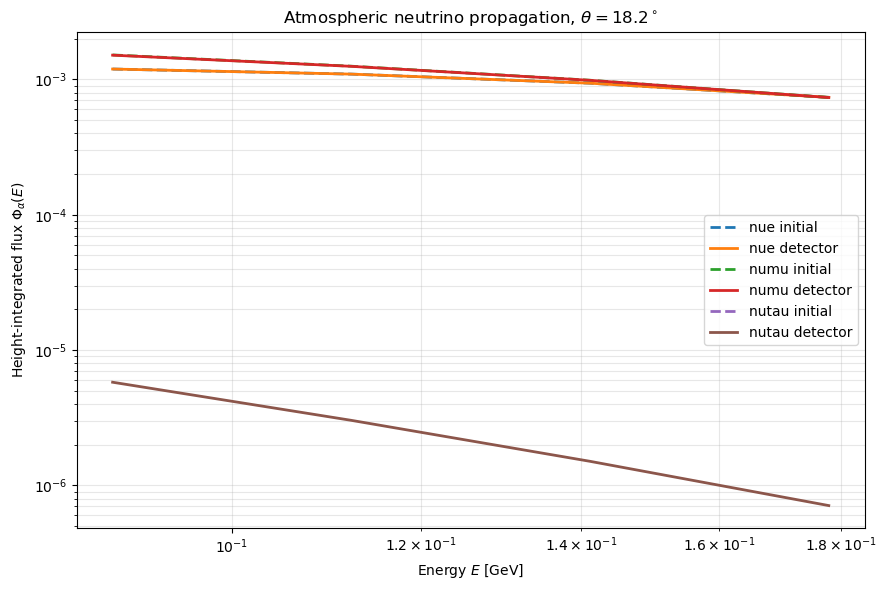

Saved plot: V:\output\test\atmosphere\test6_fluxt\test_atmosphere_flux_diagnostics_figure_003.png


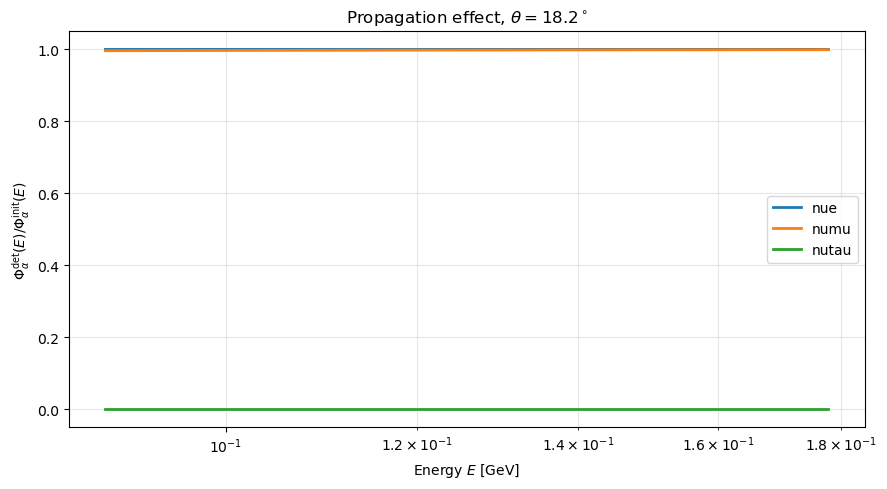

Saved plot: V:\output\test\atmosphere\test6_fluxt\test_atmosphere_flux_diagnostics_figure_004.png


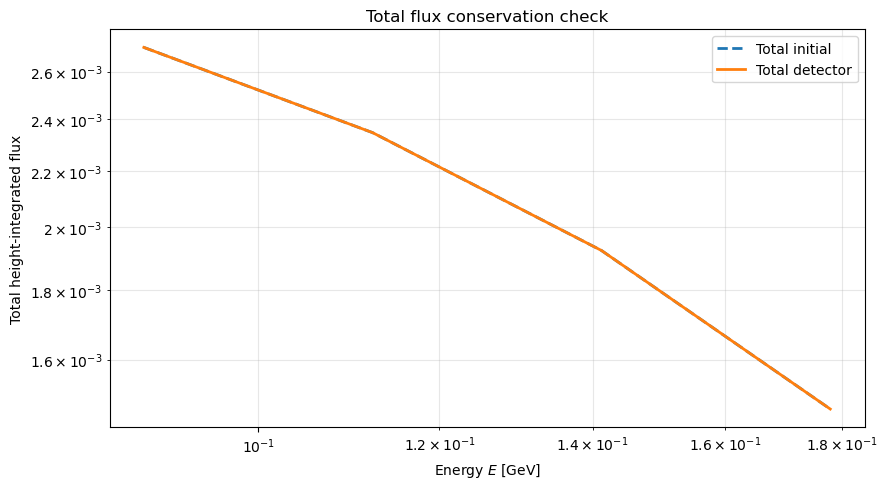

------------------------------------------------------------------------------------------
PASSED: test_atmosphere_flux_diagnostics


In [4]:
run_notebook_test(TEST_MODULE.test_atmosphere_flux_diagnostics)
